**Phần 1. Đọc dữ liệu**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [22]:
  df = pd.read_csv("data/online_retail_II.csv")
  print(df.shape)
  df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [23]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

**Phần 2. Khám phá dữ liệu**

In [24]:
df = df.rename(columns={"Invoice": "InvoiceNo", "Price": "UnitPrice", "Customer ID": "CustomerID"})
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   InvoiceNo    1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   UnitPrice    1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [25]:
print("Số dòng:", len(df))
print("Thời gian:", df["InvoiceDate"].min(), "->", df["InvoiceDate"].max())
print("\nGiá trị thiếu theo cột:")
print(df.isna().sum())
print("\nDòng trùng lặp:", df.duplicated().sum())
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())
print("Đơn hủy (InvoiceNo bắt đầu bằng C):", df["InvoiceNo"].astype(str).str.startswith("C").sum())

Số dòng: 1067371
Thời gian: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00

Giá trị thiếu theo cột:
InvoiceNo           0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     243007
Country             0
dtype: int64

Dòng trùng lặp: 34335
Quantity <= 0: 22950
UnitPrice <= 0: 6207
Đơn hủy (InvoiceNo bắt đầu bằng C): 19494


In [26]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


**Phần 3. Làm sạch dữ liệu**

In [27]:
log = {"Ban đầu": len(df)}

df = df.dropna(subset=["CustomerID"])
log["Bỏ dòng thiếu CustomerID"] = len(df)

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
log["Bỏ đơn hủy (InvoiceNo bắt đầu bằng C)"] = len(df)

df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
log["Bỏ Quantity hoặc UnitPrice <= 0"] = len(df)

df = df.drop_duplicates()
log["Bỏ dòng trùng lặp"] = len(df)

df["CustomerID"] = df["CustomerID"].astype(int)
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

log_df = pd.DataFrame({"Số dòng còn lại": pd.Series(log)})
log_df["Số dòng bị loại"] = -log_df["Số dòng còn lại"].diff().fillna(0).astype(int)
log_df

,Số dòng còn lại,Số dòng bị loại
Ban đầu,1067371,0
Bỏ dòng thiếu CustomerID,824364,243007
Bỏ đơn hủy (InvoiceNo bắt đầu bằng C),805620,18744
Bỏ Quantity hoặc UnitPrice <= 0,805549,71
Bỏ dòng trùng lặp,779425,26124


In [28]:
print("Số dòng sau làm sạch:", len(df))
print("Tỷ lệ giữ lại: {:.1f}%".format(len(df) / log["Ban đầu"] * 100))
print("Số khách hàng:", df["CustomerID"].nunique())
print("Thiếu giá trị:", df.isna().sum().sum())
df[["Quantity", "UnitPrice", "TotalPrice"]].describe()

Số dòng sau làm sạch: 779425
Tỷ lệ giữ lại: 73.0%
Số khách hàng: 5878
Thiếu giá trị: 0


,Quantity,UnitPrice,TotalPrice
count,779425.000000,779425.000000,779425.000000
mean,13.489370,3.218488,22.291823
std,145.855814,29.676140,227.427075
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.480000
75%,12.000000,3.750000,19.800000
max,80995.000000,10953.500000,168469.600000


**Phần 4: Tính RFM**

In [29]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
).reset_index()

print("Số khách hàng:", rfm.shape[0])
rfm.describe()

Số khách hàng: 5878


,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,2955.904095
std,1715.572666,209.338707,13.009406,14440.852688
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,342.280000
50%,15314.500000,96.000000,3.000000,867.740000
75%,16797.750000,380.000000,7.000000,2248.305000
max,18287.000000,739.000000,398.000000,580987.040000


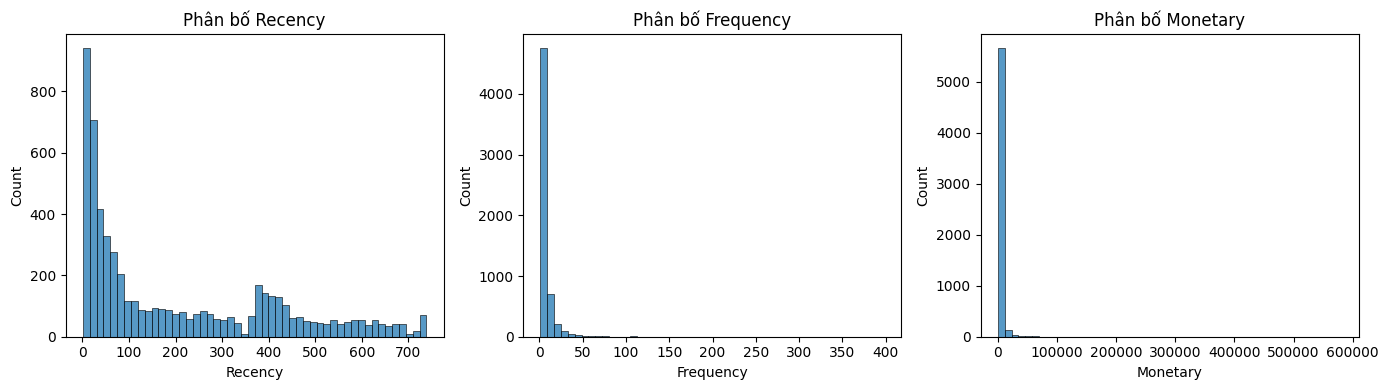

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, col in zip(ax, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], bins=50, ax=a)
    a.set_title(f"Phân bố {col}")
plt.tight_layout()
plt.savefig("output/rfm_distribution.png", dpi=150)
plt.show()

**Phần 5: Log và chuẩn hóa**

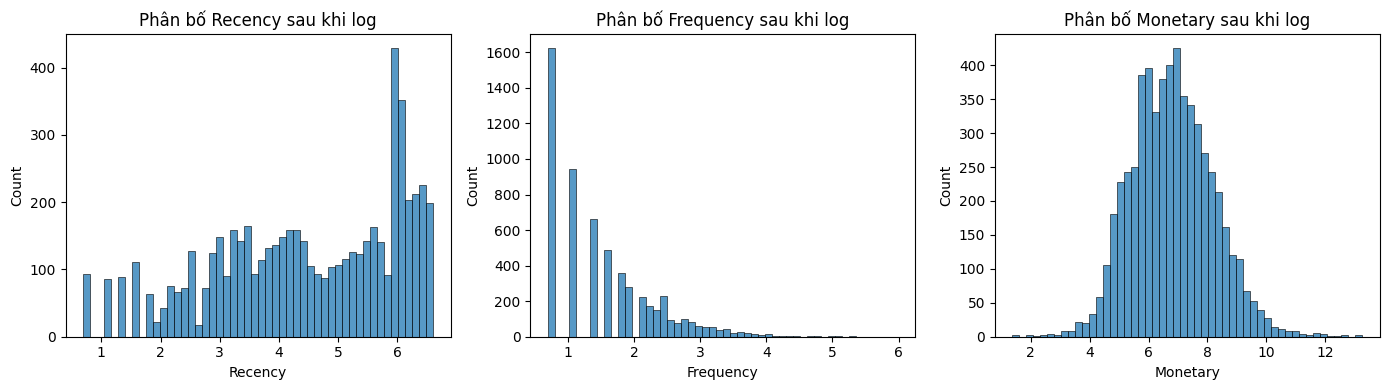

In [31]:
rfm_log = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, col in zip(ax, rfm_log.columns):
    sns.histplot(rfm_log[col], bins=50, ax=a)
    a.set_title(f"Phân bố {col} sau khi log")
plt.tight_layout()
plt.savefig("output/rfm_distribution_log.png", dpi=150)
plt.show()

In [32]:
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)

print("Trung bình:", X.mean(axis=0).round(2))
print("Độ lệch chuẩn:", X.std(axis=0).round(2))

Trung bình: [-0.  0.  0.]
Độ lệch chuẩn: [1. 1. 1.]


**Phần 6: Chọn K**

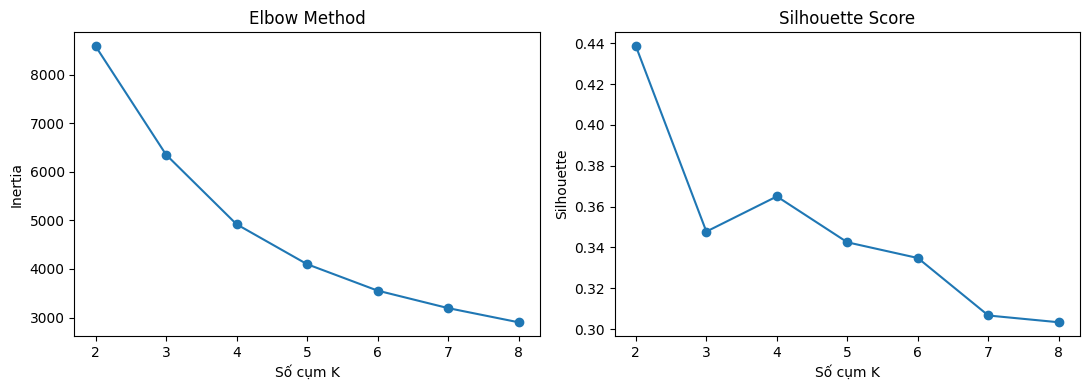

In [33]:
ks = range(2, 9)
inertia, sil = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertia, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_ylabel("Inertia")
ax[1].plot(ks, sil, marker="o")
ax[1].set_title("Silhouette Score")
ax[1].set_ylabel("Silhouette")
for a in ax:
    a.set_xlabel("Số cụm K")
plt.tight_layout()
plt.savefig("output/elbow_silhouette.png", dpi=150)
plt.show()

In [34]:
pd.DataFrame({"K": list(ks), "Inertia": np.round(inertia, 1), "Silhouette": np.round(sil, 3)})

,K,Inertia,Silhouette
0,2,8589.0,0.439
1,3,6354.3,0.348
2,4,4921.2,0.365
3,5,4099.1,0.342
4,6,3554.7,0.335
5,7,3194.5,0.307
6,8,2902.4,0.303


**Phần 7: Phân cụm**

In [35]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X)

print("Silhouette:", round(silhouette_score(X, rfm["Cluster"]), 3))
rfm["Cluster"].value_counts().sort_index()

Silhouette: 0.365


Cluster
0    1973
1    1250
2    1196
3    1459
Name: count, dtype: int64

In [36]:
profile = rfm.groupby("Cluster").agg(
    So_khach=("CustomerID", "count"),
    Recency_TB=("Recency", "mean"),
    Frequency_TB=("Frequency", "mean"),
    Monetary_TB=("Monetary", "mean"),
    Monetary_tong=("Monetary", "sum"),
).round(1)

profile["% khach"] = (profile["So_khach"] / len(rfm) * 100).round(1)
profile["% doanh thu"] = (profile["Monetary_tong"] / rfm["Monetary"].sum() * 100).round(1)
profile

,So_khach,Recency_TB,Frequency_TB,Monetary_TB,Monetary_tong,% khach,% doanh thu
Cluster,,,,,,,
0,1973,394.9,1.4,317.1,625601.8,33.6,3.6
1,1250,28.3,3.1,857.5,1071864.3,21.3,6.2
2,1196,27.7,19.3,10731.2,12834470.9,20.3,73.9
3,1459,230.1,5.1,1948.5,2842867.2,24.8,16.4


**Phần 8: Kết quả và đề xuất**

In [37]:
names = {2: "VIP", 1: "Tiềm năng", 3: "Nguy cơ rời bỏ", 0: "Đã rời bỏ"}
order = ["VIP", "Tiềm năng", "Nguy cơ rời bỏ", "Đã rời bỏ"]
rfm["Segment"] = rfm["Cluster"].map(names)
rfm["Segment"].value_counts().reindex(order)

Segment
VIP               1196
Tiềm năng         1250
Nguy cơ rời bỏ    1459
Đã rời bỏ         1973
Name: count, dtype: int64

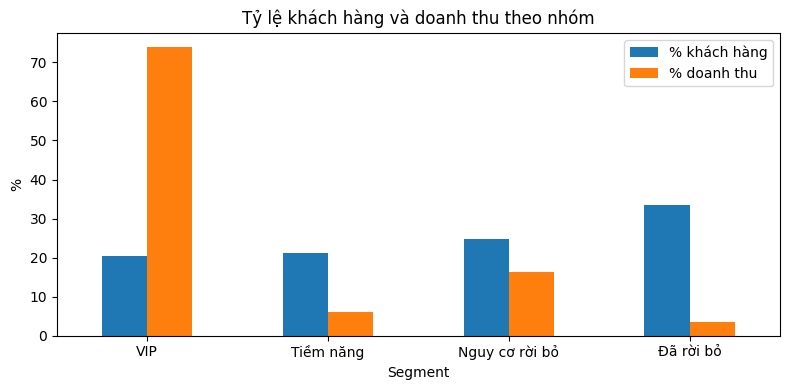

In [38]:
share = rfm.groupby("Segment").agg(khach=("CustomerID", "count"), doanhthu=("Monetary", "sum")).reindex(order)
share = share / share.sum() * 100
share.columns = ["% khách hàng", "% doanh thu"]

ax = share.plot(kind="bar", figsize=(8, 4))
ax.set_title("Tỷ lệ khách hàng và doanh thu theo nhóm")
ax.set_ylabel("%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("output/segment_share.png", dpi=150)
plt.show()

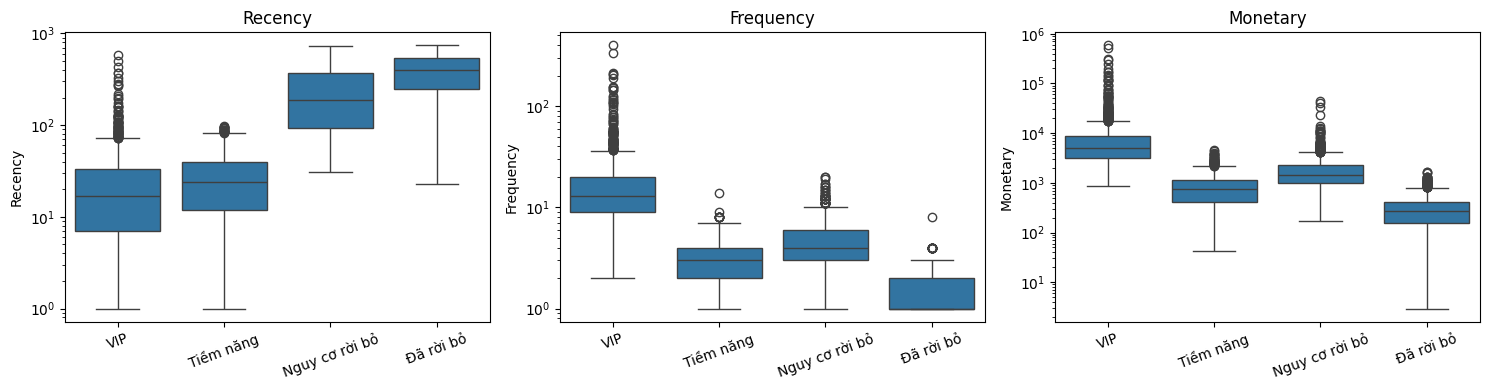

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, ["Recency", "Frequency", "Monetary"]):
    sns.boxplot(data=rfm, x="Segment", y=col, order=order, ax=a)
    a.set_yscale("log")
    a.set_title(col)
    a.set_xlabel("")
    a.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("output/rfm_by_segment.png", dpi=150)
plt.show()

In [40]:
rfm.to_csv("output/rfm_segments.csv", index=False)